##Library

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from PIL import Image
from pathlib import Path
from tqdm import tqdm
from scipy.stats import skew, kurtosis
from skimage.feature import graycomatrix, graycoprops, local_binary_pattern
from skimage.color import rgb2gray
from skimage import img_as_ubyte
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.manifold import TSNE
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
import os
import shutil
import math
from pathlib import Path

##Mount Google Drive

In [29]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


##KONFIGURASI CITRA

In [30]:
DATASET_PATH = '/content/drive/MyDrive/Colab Notebooks/Daun Pepaya dan Jagung'
OUTPUT_PATH  = '/content/drive/MyDrive/Colab Notebooks/Daun Pepaya dan Jagung/hasil'
K_MANUAL      = None
K_RANGE       = range(2, 11)
RANDOM_STATE  = 42
N_INIT        = 20
MAX_ITER      = 500
IMG_SIZE      = (128, 128)
CONVERT_GRAY  = True
VALID_EXT = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.tif'}
GLCM_DISTANCES = [1, 3, 5]
GLCM_ANGLES    = [0, 45, 90, 135]
PCA_VARIANCE   = 0.95

os.makedirs(OUTPUT_PATH, exist_ok=True)
print(f'Konfigurasi siap!')
print(f'Dataset : {DATASET_PATH}')
print(f'Output  : {OUTPUT_PATH}')
print(f'Ukuran  : {IMG_SIZE}, Grayscale={CONVERT_GRAY}')

Konfigurasi siap!
Dataset : /content/drive/MyDrive/Colab Notebooks/Daun Pepaya dan Jagung
Output  : /content/drive/MyDrive/Colab Notebooks/Daun Pepaya dan Jagung/hasil
Ukuran  : (128, 128), Grayscale=True


##Load & Validasi Dataset

In [31]:
def load_images_from_folder(folder_path, valid_ext, img_size, convert_gray):
    images, filenames, labels = [], [], []
    folder = Path(folder_path)
    output_folder = Path(OUTPUT_PATH)
    all_files = [
        p for p in folder.rglob('*')
        if p.suffix.lower() in valid_ext
        and not str(p).startswith(str(output_folder))
    ]

    if not all_files:
        raise FileNotFoundError(
            f"Tidak ada citra ditemukan di '{folder_path}'.\n"
            f"Pastikan path sudah benar dan folder berisi file {valid_ext}"
        )

    print(f'Ditemukan {len(all_files)} file citra...')

    failed = []
    for fpath in tqdm(all_files, desc='Loading citra'):
        try:
            img = Image.open(fpath).convert('RGB')
            img = img.resize(img_size, Image.LANCZOS)
            img_arr = np.array(img)

            if convert_gray:
                img_arr = np.array(img.convert('L'))

            images.append(img_arr)
            filenames.append(fpath.name)
            parent = fpath.parent.name
            labels.append(parent if parent != folder.name else 'unknown')
        except Exception as e:
            failed.append((fpath.name, str(e)))

    if failed:
        print(f'{len(failed)} file gagal dibuka:')
        for fname, err in failed[:5]:
            print(f'   - {fname}: {err}')

    print(f'\nBerhasil load: {len(images)} citra')
    print(f'   Shape sample  : {images[0].shape}')
    return images, filenames, labels


images, filenames, true_labels = load_images_from_folder(
    DATASET_PATH, VALID_EXT, IMG_SIZE, CONVERT_GRAY
)
label_series = pd.Series(true_labels)
print(f'\n Distribusi kelas (subfolder):')
print(label_series.value_counts().to_string())

Ditemukan 139 file citra...


Loading citra: 100%|██████████| 139/139 [00:01<00:00, 96.91it/s] 


Berhasil load: 139 citra
   Shape sample  : (128, 128)

 Distribusi kelas (subfolder):
unknown    139


##Tampilkan Sampel Citra

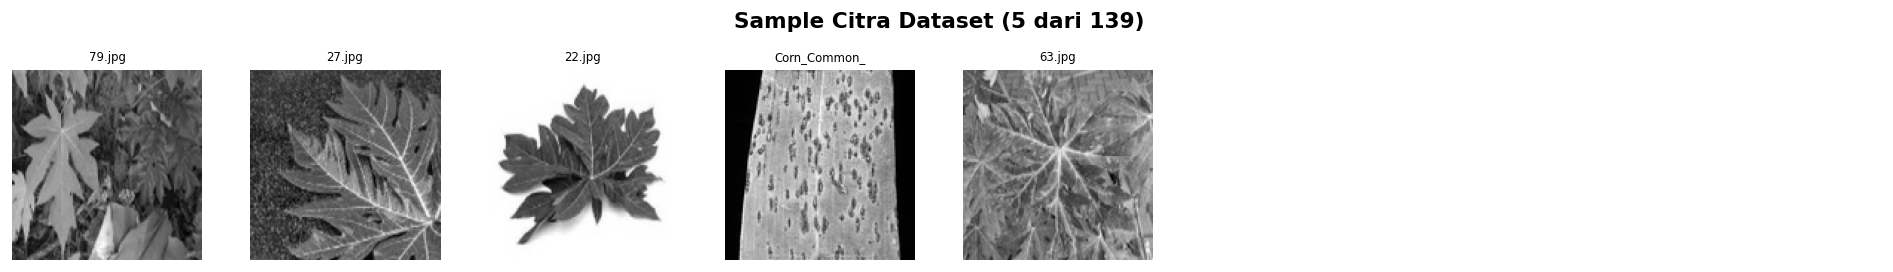

Tersimpan: sample_citra.png


In [32]:
def show_sample_images(images, filenames, n=16, cmap='gray'):
    n = min(n, len(images))
    indices = np.random.choice(len(images), n, replace=False)
    cols = 8
    rows = (n + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2.2))
    axes = axes.flatten()

    for i, idx in enumerate(indices):
        axes[i].imshow(images[idx], cmap=cmap)
        axes[i].set_title(filenames[idx][:12], fontsize=7)
        axes[i].axis('off')

    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.suptitle(f'Sample Citra Dataset ({n} dari {len(images)})',
                 fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_PATH}/sample_citra.png', bbox_inches='tight', dpi=120)
    plt.show()
    print('Tersimpan: sample_citra.png')

show_sample_images(images, filenames, n=5)

##Fungsi Ekstraksi Fitur Tekstur

In [33]:
def extract_glcm_features(img_gray, distances, angles_deg):
    angles_rad = [math.radians(a) for a in angles_deg]
    glcm = graycomatrix(
        img_as_ubyte(img_gray),
        distances=distances,
        angles=angles_rad,
        levels=256,
        symmetric=True,
        normed=True
    )

    props = ['contrast', 'dissimilarity', 'homogeneity', 'energy', 'correlation', 'ASM']
    features = {}

    for prop in props:
        vals = graycoprops(glcm, prop)
        features[f'glcm_{prop}_mean'] = vals.mean()
        features[f'glcm_{prop}_std']  = vals.std()

    return features
def extract_lbp_features(img_gray, radius=3, n_points=None, n_bins=32):
    if n_points is None:
        n_points = 8 * radius

    lbp = local_binary_pattern(img_gray, n_points, radius, method='uniform')
    hist, _ = np.histogram(lbp.ravel(), bins=n_bins,
                           range=(0, n_points + 2), density=True)

    features = {f'lbp_bin_{i:02d}': v for i, v in enumerate(hist)}
    features['lbp_mean'] = lbp.mean()
    features['lbp_std']  = lbp.std()
    return features
def extract_stat_features(img_gray):
    flat = img_gray.flatten().astype(np.float64)
    hist, _ = np.histogram(flat, bins=256, range=(0, 256), density=True)
    hist = hist[hist > 0]
    entropy = -np.sum(hist * np.log2(hist))
    blocks = flat.reshape(-1, 16) if len(flat) % 16 == 0 else flat[:-(len(flat)%16)].reshape(-1, 16)
    var_of_var = np.var([np.var(b) for b in blocks])

    return {
        'stat_mean'      : np.mean(flat),
        'stat_std'       : np.std(flat),
        'stat_skewness'  : skew(flat),
        'stat_kurtosis'  : kurtosis(flat),
        'stat_min'       : np.min(flat),
        'stat_max'       : np.max(flat),
        'stat_median'    : np.median(flat),
        'stat_range'     : np.max(flat) - np.min(flat),
        'stat_entropy'   : entropy,
        'stat_var_of_var': var_of_var,
        'stat_energy'    : np.sum(flat**2) / len(flat),
        'stat_rms'       : np.sqrt(np.mean(flat**2)),
    }
def extract_all_features(img_gray, glcm_distances, glcm_angles):
    features = {}
    features.update(extract_glcm_features(img_gray, glcm_distances, glcm_angles))
    features.update(extract_lbp_features(img_gray))
    features.update(extract_stat_features(img_gray))
    return features


print('Fungsi ekstraksi fitur tekstur siap!')
print('GLCM  : contrast, dissimilarity, homogeneity, energy, correlation, ASM')
print('LBP   : histogram 32-bin + mean & std')
print('Stat  : mean, std, skewness, kurtosis, min, max, median, entropy, dll')

Fungsi ekstraksi fitur tekstur siap!
GLCM  : contrast, dissimilarity, homogeneity, energy, correlation, ASM
LBP   : histogram 32-bin + mean & std
Stat  : mean, std, skewness, kurtosis, min, max, median, entropy, dll


##Jalankan Ekstraksi Fitur

In [34]:
all_features = []

for i, img in enumerate(tqdm(images, desc='Ekstraksi fitur')):
    if img.ndim == 3:
        img_gray = rgb2gray(img)
    else:
        img_gray = img.astype(np.float64) / 255.0

    feats = extract_all_features(
        img_gray,
        GLCM_DISTANCES,
        GLCM_ANGLES
    )
    all_features.append(feats)
df_features = pd.DataFrame(all_features)
df_features.insert(0, 'filename', filenames)
df_features.insert(1, 'true_label', true_labels)

print(f'\nEkstraksi selesai!')
print(f'   Jumlah citra     : {len(df_features)}')
print(f'   Jumlah fitur     : {df_features.shape[1] - 2}')
print(f'\nPreview DataFrame:')
df_features.head(3)

Ekstraksi fitur: 100%|██████████| 139/139 [00:19<00:00,  7.02it/s]


Ekstraksi selesai!
   Jumlah citra     : 139
   Jumlah fitur     : 58

Preview DataFrame:


,filename,true_label,glcm_contrast_mean,glcm_contrast_std,glcm_dissimilarity_mean,glcm_dissimilarity_std,glcm_homogeneity_mean,glcm_homogeneity_std,glcm_energy_mean,glcm_energy_std,...,stat_skewness,stat_kurtosis,stat_min,stat_max,stat_median,stat_range,stat_entropy,stat_var_of_var,stat_energy,stat_rms
0,Corn_Blight (1).jpeg,unknown,1203.028256,686.074283,20.819629,7.863374,0.101493,0.046139,0.012439,0.002140,...,-0.283093,-0.255976,0.031373,1.000000,0.549020,0.968627,0.009942,0.000125,0.329988,0.574446
1,Corn_Blight (1).jpg,unknown,541.028724,403.942651,11.318617,5.172884,0.214067,0.064948,0.036151,0.006058,...,0.444885,-1.579786,0.207843,0.882353,0.415686,0.674510,-0.000000,0.000125,0.333219,0.577251
2,Corn_Blight (10).jpg,unknown,2290.685782,1154.411990,31.902746,10.322712,0.064553,0.030469,0.010100,0.001521,...,0.698669,0.091208,0.000000,1.000000,0.380392,1.000000,0.066341,0.000629,0.216336,0.465120


##Simpan Fitur ke CSV

In [35]:
csv_path = f'{OUTPUT_PATH}/fitur_tekstur.csv'
df_features.to_csv(csv_path, index=False)
print(f'Fitur tersimpan: {csv_path}')
missing = df_features.isnull().sum().sum()
print(f'   Missing values  : {missing}')
if missing > 0:
    print('Mengisi NaN dengan median kolom...')
    df_features.fillna(df_features.median(numeric_only=True), inplace=True)
feature_cols = [c for c in df_features.columns if c not in ['filename', 'true_label']]
X_raw = df_features[feature_cols].values
print(f'\nShape matriks fitur X : {X_raw.shape}')

Fitur tersimpan: /content/drive/MyDrive/Colab Notebooks/Daun Pepaya dan Jagung/hasil/fitur_tekstur.csv
   Missing values  : 0

Shape matriks fitur X : (139, 58)


##Visualisasi Distribusi Fitur

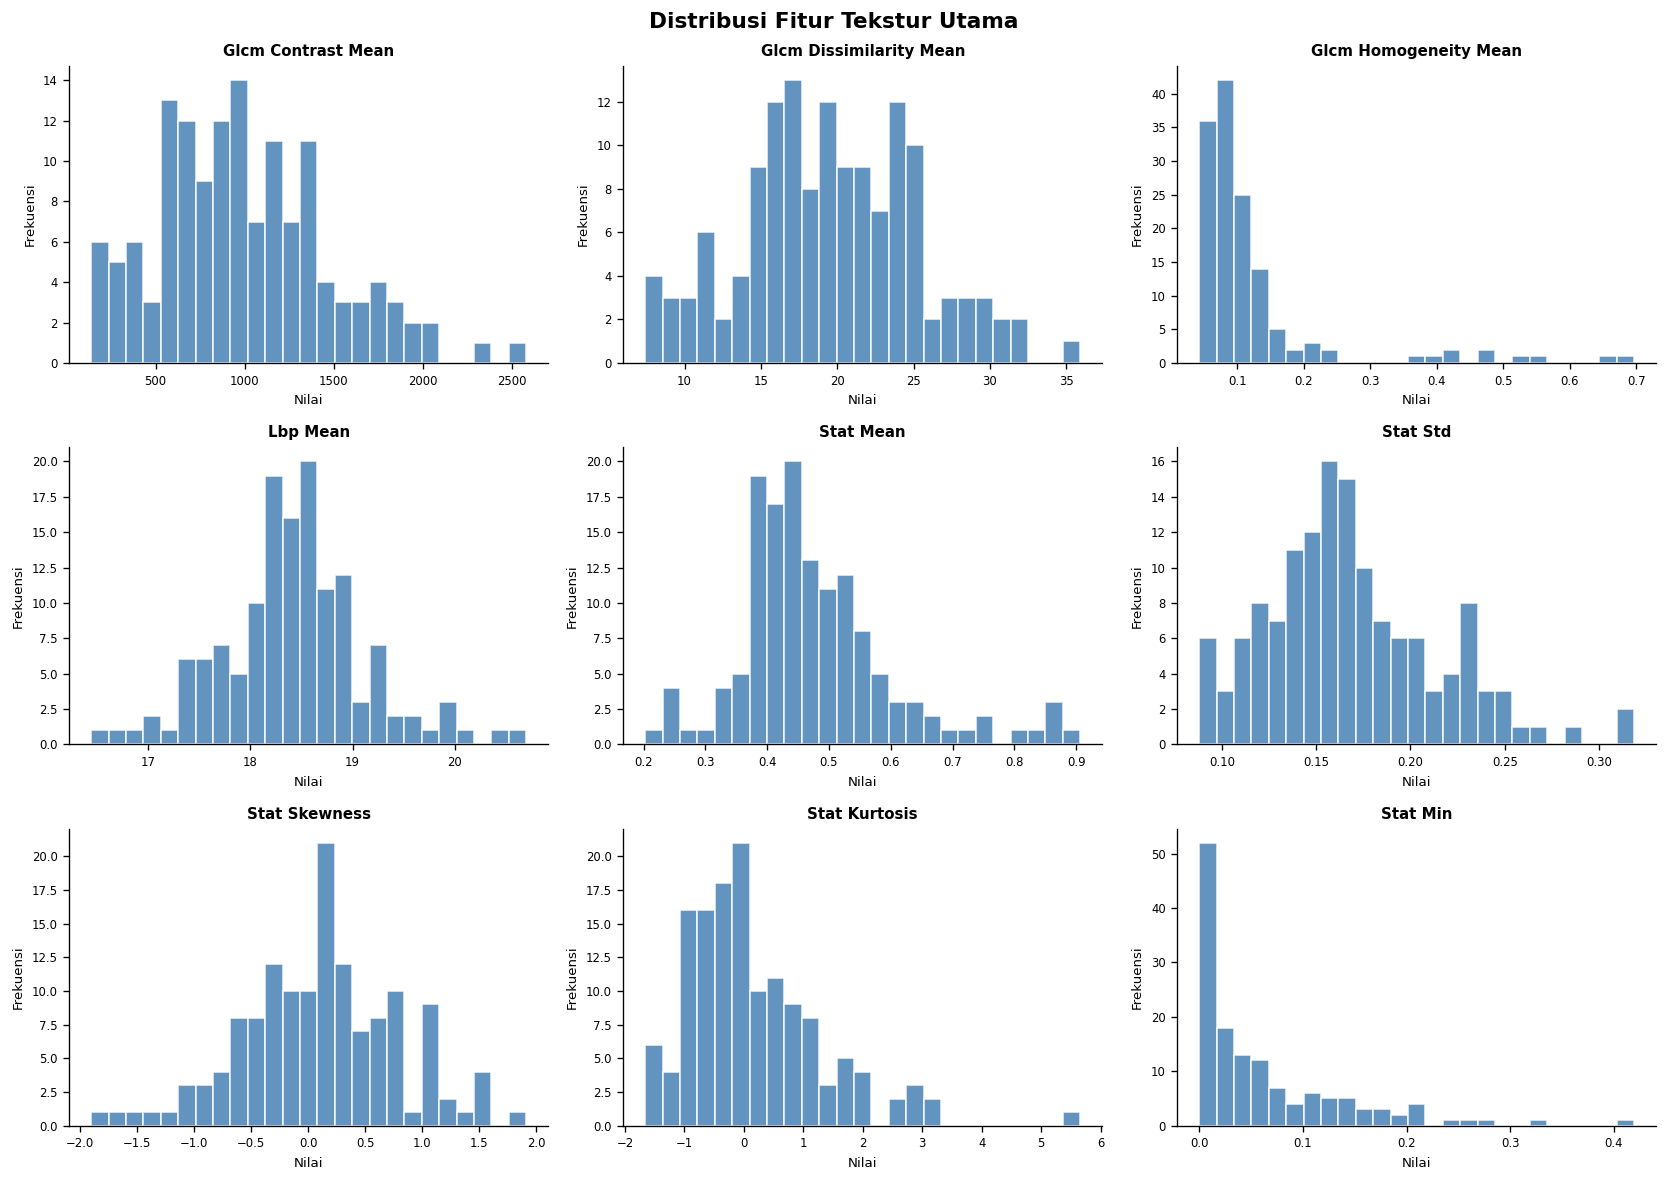

Tersimpan: distribusi_fitur.png


In [36]:
# Auto-detect fitur dari tiap grup (tidak hardcode nama kolom)
glcm_feats = [c for c in df_features.columns if 'glcm' in c and c.endswith('_mean')]
lbp_feats  = [c for c in df_features.columns if c.startswith('lbp') and 'bin' not in c]
stat_feats = [c for c in df_features.columns if c.startswith('stat')]
key_features = (glcm_feats[:3] + lbp_feats[:1] + stat_feats[:5])[:9]

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

for i, feat in enumerate(key_features[:9]):
    axes[i].hist(df_features[feat], bins=25, color='steelblue',
                 edgecolor='white', alpha=0.85)
    axes[i].set_title(feat.replace('_', ' ').title(), fontsize=9, fontweight='bold')
    axes[i].set_xlabel('Nilai', fontsize=8)
    axes[i].set_ylabel('Frekuensi', fontsize=8)
    axes[i].tick_params(labelsize=7)
    axes[i].spines[['top','right']].set_visible(False)

plt.suptitle('Distribusi Fitur Tekstur Utama', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_PATH}/distribusi_fitur.png', bbox_inches='tight')
plt.show()
print('Tersimpan: distribusi_fitur.png')

##Normalisasi & PCA

   Normalisasi selesai (StandardScaler)
   Mean setelah scaling  : 0.0000  (harusnya ≈ 0)
   Std  setelah scaling  : 0.9469  (harusnya ≈ 1)

 PCA selesai!
   Dimensi awal          : 58
   Dimensi setelah PCA   : 13
   Varian tertangkap     : 95.23%


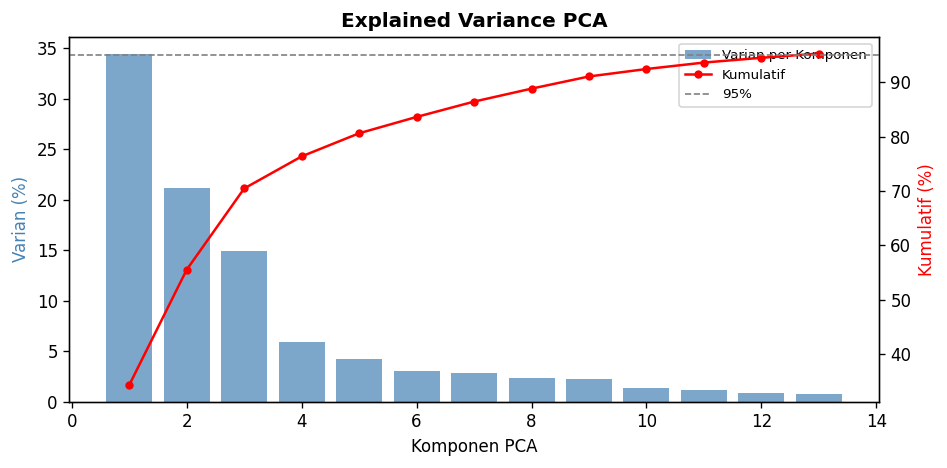

Tersimpan: pca_variance.png


In [37]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)
print(f'   Normalisasi selesai (StandardScaler)')
print(f'   Mean setelah scaling  : {X_scaled.mean():.4f}  (harusnya ≈ 0)')
print(f'   Std  setelah scaling  : {X_scaled.std():.4f}  (harusnya ≈ 1)')
pca = PCA(n_components=PCA_VARIANCE, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

print(f'\n PCA selesai!')
print(f'   Dimensi awal          : {X_scaled.shape[1]}')
print(f'   Dimensi setelah PCA   : {X_pca.shape[1]}')
print(f'   Varian tertangkap     : {pca.explained_variance_ratio_.sum()*100:.2f}%')
cumvar = np.cumsum(pca.explained_variance_ratio_) * 100
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(1, len(cumvar)+1), pca.explained_variance_ratio_*100,
       color='steelblue', alpha=0.7, label='Varian per Komponen')
ax2 = ax.twinx()
ax2.plot(range(1, len(cumvar)+1), cumvar, 'r-o', ms=4, label='Kumulatif')
ax2.axhline(95, color='gray', ls='--', lw=1, label='95%')
ax.set_xlabel('Komponen PCA')
ax.set_ylabel('Varian (%)', color='steelblue')
ax2.set_ylabel('Kumulatif (%)', color='red')
ax.set_title('Explained Variance PCA', fontweight='bold')
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1+lines2, labels1+labels2, fontsize=8)
plt.tight_layout()
plt.savefig(f'{OUTPUT_PATH}/pca_variance.png', bbox_inches='tight')
plt.show()
print('Tersimpan: pca_variance.png')

##Elbow Method (Menentukan K Optimal)

Menjalankan Elbow Method...


Elbow K-Means: 100%|██████████| 9/9 [00:00<00:00, 16.44it/s]



Hasil Elbow Method:
   K Elbow (Inertia)     : 4
   K Silhouette Terbaik  : 2  (score=0.5304)


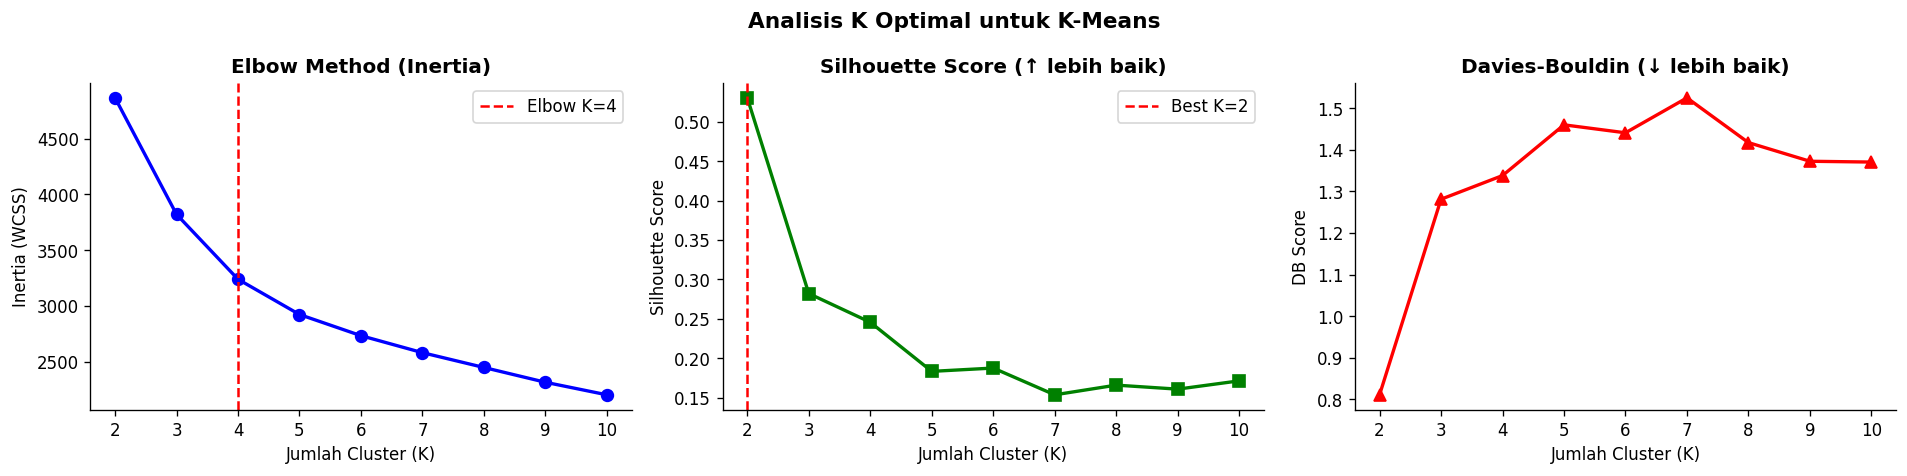

Tersimpan: elbow_method.png


In [38]:
inertias      = []
silhouettes   = []
db_scores     = []
ch_scores     = []

print('Menjalankan Elbow Method...')
for k in tqdm(K_RANGE, desc='Elbow K-Means'):
    km = KMeans(n_clusters=k, n_init=N_INIT, max_iter=MAX_ITER,
                random_state=RANDOM_STATE)
    labels_k = km.fit_predict(X_pca)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_pca, labels_k))
    db_scores.append(davies_bouldin_score(X_pca, labels_k))
    ch_scores.append(calinski_harabasz_score(X_pca, labels_k))
def find_elbow(inertias, k_range):
    k_list = list(k_range)
    coords = np.column_stack([k_list, inertias])
    first, last = coords[0], coords[-1]
    line_vec = last - first
    line_vec_norm = line_vec / np.linalg.norm(line_vec)
    vecs = coords - first
    dists = np.abs(np.cross(line_vec_norm, vecs))
    return k_list[np.argmax(dists)]

elbow_k = find_elbow(inertias, K_RANGE)
best_sil_k = list(K_RANGE)[np.argmax(silhouettes)]

print(f'\nHasil Elbow Method:')
print(f'   K Elbow (Inertia)     : {elbow_k}')
print(f'   K Silhouette Terbaik  : {best_sil_k}  (score={max(silhouettes):.4f})')
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
k_list = list(K_RANGE)

axes[0].plot(k_list, inertias, 'bo-', ms=7, lw=2)
axes[0].axvline(elbow_k, color='red', ls='--', lw=1.5, label=f'Elbow K={elbow_k}')
axes[0].set_title('Elbow Method (Inertia)', fontweight='bold')
axes[0].set_xlabel('Jumlah Cluster (K)')
axes[0].set_ylabel('Inertia (WCSS)')
axes[0].legend(); axes[0].spines[['top','right']].set_visible(False)

axes[1].plot(k_list, silhouettes, 'gs-', ms=7, lw=2)
axes[1].axvline(best_sil_k, color='red', ls='--', lw=1.5, label=f'Best K={best_sil_k}')
axes[1].set_title('Silhouette Score (↑ lebih baik)', fontweight='bold')
axes[1].set_xlabel('Jumlah Cluster (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].legend(); axes[1].spines[['top','right']].set_visible(False)

axes[2].plot(k_list, db_scores, 'r^-', ms=7, lw=2)
axes[2].set_title('Davies-Bouldin (↓ lebih baik)', fontweight='bold')
axes[2].set_xlabel('Jumlah Cluster (K)')
axes[2].set_ylabel('DB Score')
axes[2].spines[['top','right']].set_visible(False)

plt.suptitle('Analisis K Optimal untuk K-Means', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_PATH}/elbow_method.png', bbox_inches='tight')
plt.show()
print('Tersimpan: elbow_method.png')

##Training K-Means

In [39]:
if K_MANUAL is not None:
    K_FINAL = K_MANUAL
    print(f'Menggunakan K manual: {K_FINAL}')
else:
    K_FINAL = best_sil_k   # pakai K terbaik dari silhouette
    print(f'K otomatis (Silhouette terbaik): {K_FINAL}')
    print(f'   (Elbow K={elbow_k}, bisa diganti manual di konfigurasi)')

kmeans_final = KMeans(
    n_clusters=K_FINAL,
    n_init=N_INIT,
    max_iter=MAX_ITER,
    random_state=RANDOM_STATE
)
cluster_labels = kmeans_final.fit_predict(X_pca)

sil   = silhouette_score(X_pca, cluster_labels)
db    = davies_bouldin_score(X_pca, cluster_labels)
ch    = calinski_harabasz_score(X_pca, cluster_labels)
inert = kmeans_final.inertia_

print(f'\nK-Means selesai! K = {K_FINAL}')
print(f'\nMetrik Evaluasi Clustering:')
print(f'   Silhouette Score     : {sil:.4f}  (range -1 s/d 1, ↑ lebih baik)')
print(f'   Davies-Bouldin Score : {db:.4f}  (≥0, ↓ lebih baik)')
print(f'   Calinski-Harabasz    : {ch:.2f}  (↑ lebih baik)')
print(f'   Inertia (WCSS)       : {inert:.2f}')

unique, counts = np.unique(cluster_labels, return_counts=True)
print(f'\nDistribusi Anggota Cluster:')
for u, c in zip(unique, counts):
    print(f'   Cluster {u}: {c} citra ({c/len(cluster_labels)*100:.1f}%)')

K otomatis (Silhouette terbaik): 2
   (Elbow K=4, bisa diganti manual di konfigurasi)

K-Means selesai! K = 2

Metrik Evaluasi Clustering:
   Silhouette Score     : 0.5304  (range -1 s/d 1, ↑ lebih baik)
   Davies-Bouldin Score : 0.8112  (≥0, ↓ lebih baik)
   Calinski-Harabasz    : 56.86  (↑ lebih baik)
   Inertia (WCSS)       : 4864.42

Distribusi Anggota Cluster:
   Cluster 0: 10 citra (7.2%)
   Cluster 1: 129 citra (92.8%)


## Simpan Hasil Clustering

In [40]:
df_features['cluster'] = cluster_labels
df_results = df_features[['filename', 'true_label', 'cluster'] + feature_cols].copy()

result_csv = f'{OUTPUT_PATH}/hasil_clustering.csv'
df_results.to_csv(result_csv, index=False)
print(f'Hasil clustering tersimpan: {result_csv}')
eval_df = pd.DataFrame([{
    'K': K_FINAL,
    'Silhouette_Score': round(sil, 4),
    'Davies_Bouldin': round(db, 4),
    'Calinski_Harabasz': round(ch, 2),
    'Inertia': round(inert, 2),
    'N_Images': len(cluster_labels),
    'N_Features_Raw': X_raw.shape[1],
    'N_Features_PCA': X_pca.shape[1],
}])
eval_csv = f'{OUTPUT_PATH}/evaluasi_kmeans.csv'
eval_df.to_csv(eval_csv, index=False)
print(f'Evaluasi tersimpan         : {eval_csv}')

df_results[['filename', 'true_label', 'cluster']].head(10)

Hasil clustering tersimpan: /content/drive/MyDrive/Colab Notebooks/Daun Pepaya dan Jagung/hasil/hasil_clustering.csv
Evaluasi tersimpan         : /content/drive/MyDrive/Colab Notebooks/Daun Pepaya dan Jagung/hasil/evaluasi_kmeans.csv


,filename,true_label,cluster
0,Corn_Blight (1).jpeg,unknown,1
1,Corn_Blight (1).jpg,unknown,1
2,Corn_Blight (10).jpg,unknown,1
3,Corn_Blight (5).jpg,unknown,0
4,Corn_Blight (3).jpg,unknown,1
5,Corn_Blight (6).jpg,unknown,1
6,Corn_Blight (4).jpg,unknown,1
7,Corn_Blight (2).jpg,unknown,1
8,Corn_Blight (8).jpg,unknown,1
9,Corn_Blight (9).jpg,unknown,1


##Visualisasi Clustering (PCA 2D & t-SNE)

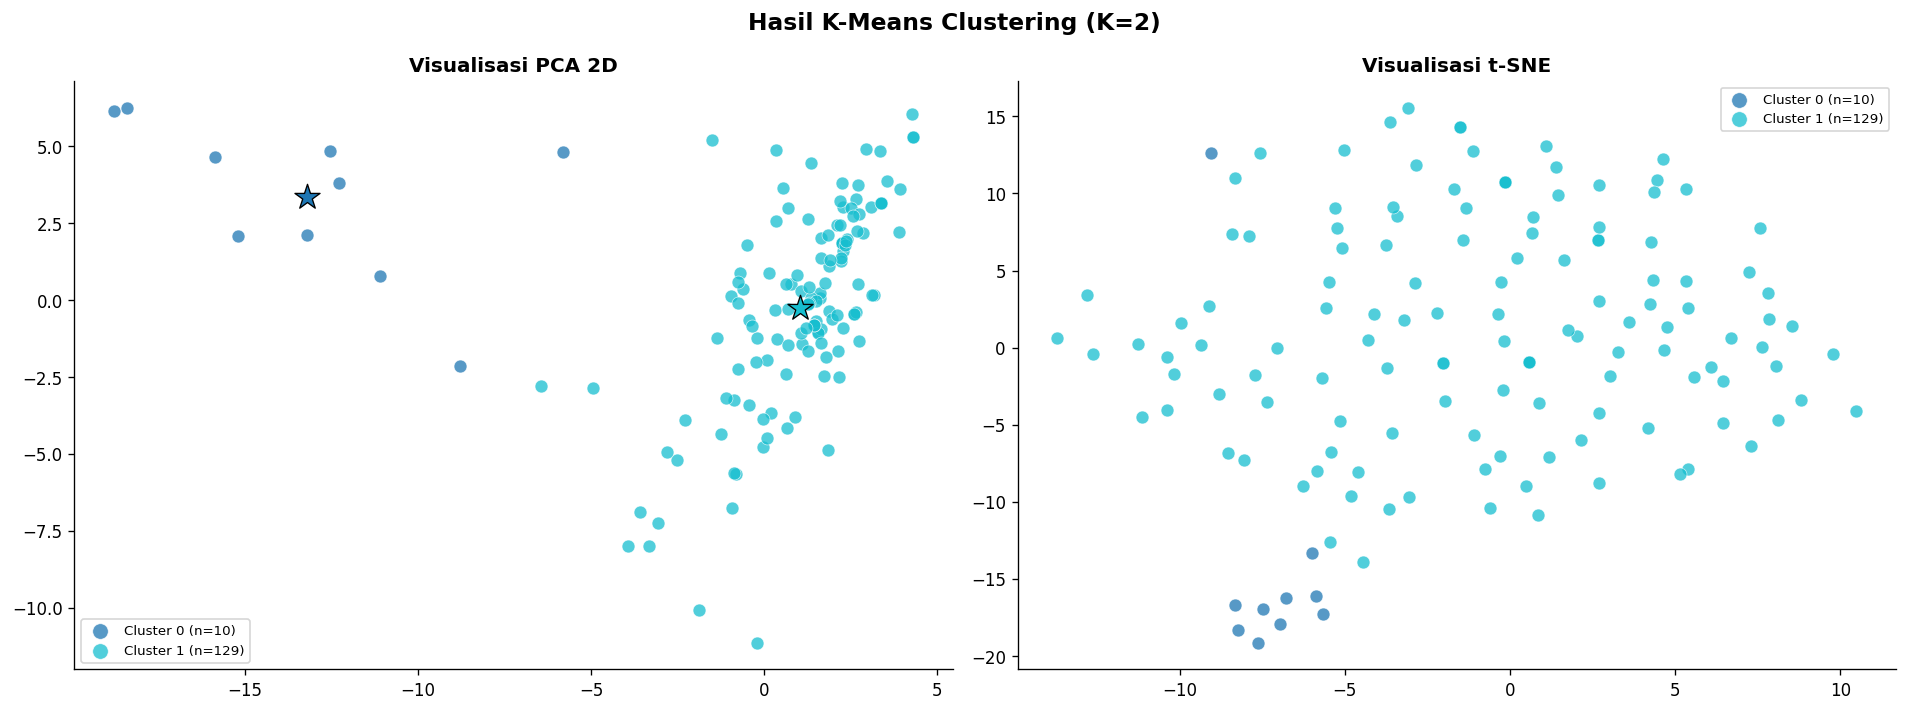

Tersimpan: visualisasi_clustering.png


In [41]:
PALETTE = plt.cm.get_cmap('tab10', K_FINAL)
pca2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_2d  = pca2d.fit_transform(X_scaled)
tsne  = TSNE(n_components=2, random_state=RANDOM_STATE,
             perplexity=min(30, len(images)-1), n_iter=1000)
X_tsne = tsne.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, X_vis, title in [
    (axes[0], X_2d, 'Visualisasi PCA 2D'),
    (axes[1], X_tsne, 'Visualisasi t-SNE')
]:
    for c in range(K_FINAL):
        mask = cluster_labels == c
        ax.scatter(X_vis[mask, 0], X_vis[mask, 1],
                   color=PALETTE(c), alpha=0.75, s=60,
                   edgecolors='white', linewidths=0.4,
                   label=f'Cluster {c} (n={mask.sum()})')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(fontsize=8, markerscale=1.2)
    ax.spines[['top','right']].set_visible(False)
centroids_2d = pca2d.transform(scaler.transform(
    scaler.inverse_transform(
        np.zeros((K_FINAL, X_scaled.shape[1]))
    )))
for c in range(K_FINAL):
    cx = X_2d[cluster_labels == c, 0].mean()
    cy = X_2d[cluster_labels == c, 1].mean()
    axes[0].scatter(cx, cy, marker='*', color=PALETTE(c), s=250,
                    edgecolors='black', linewidths=0.8, zorder=5)

plt.suptitle(f'Hasil K-Means Clustering (K={K_FINAL})', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_PATH}/visualisasi_clustering.png', bbox_inches='tight')
plt.show()
print('Tersimpan: visualisasi_clustering.png')

##Tampilkan Sampel Citra per Cluster

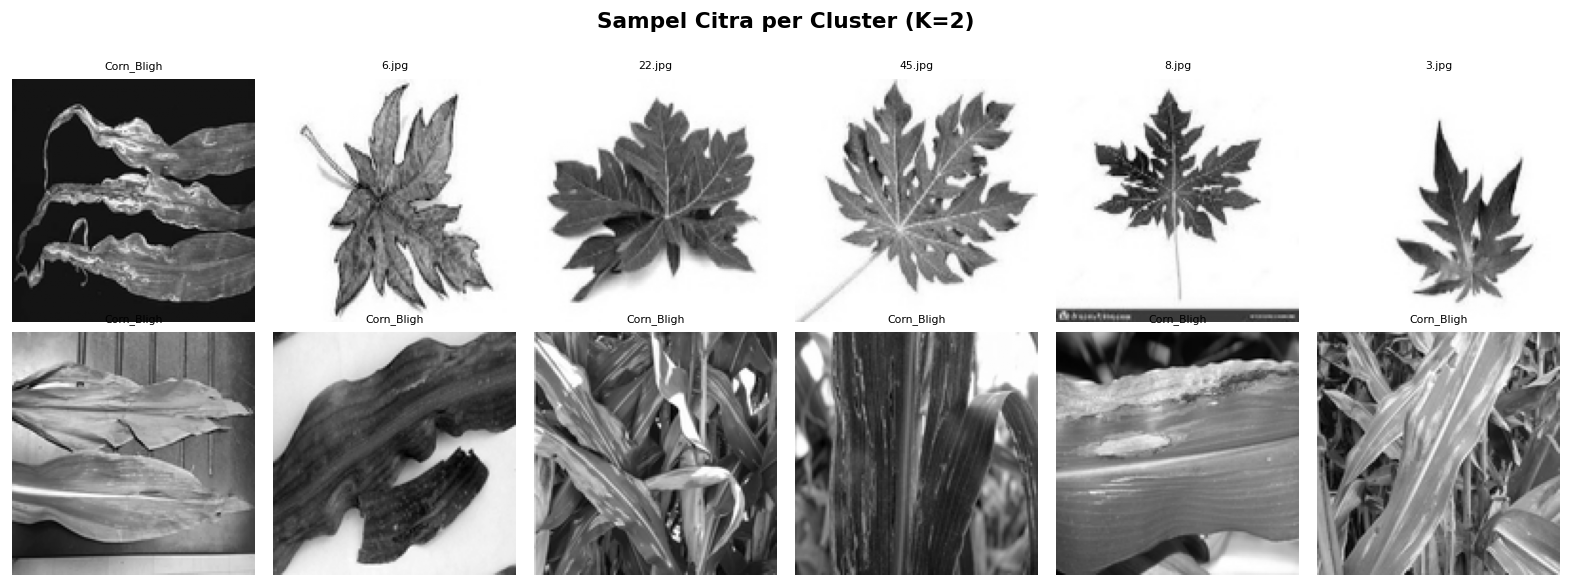

Tersimpan: sampel_per_cluster.png


In [42]:
SAMPLES_PER_CLUSTER = 6

fig, axes = plt.subplots(K_FINAL, SAMPLES_PER_CLUSTER,
                          figsize=(SAMPLES_PER_CLUSTER * 2.2, K_FINAL * 2.4))
if K_FINAL == 1:
    axes = [axes]

for c in range(K_FINAL):
    cluster_idx = np.where(cluster_labels == c)[0]
    sample_idx  = cluster_idx[:SAMPLES_PER_CLUSTER]

    for j in range(SAMPLES_PER_CLUSTER):
        ax = axes[c][j] if K_FINAL > 1 else axes[j]
        if j < len(sample_idx):
            ax.imshow(images[sample_idx[j]], cmap='gray')
            ax.set_title(filenames[sample_idx[j]][:10], fontsize=6.5)
        ax.axis('off')
    ax_label = axes[c][0] if K_FINAL > 1 else axes[0]
    ax_label.set_ylabel(f'Cluster {c}\n(n={len(cluster_idx)})',
                        fontsize=9, fontweight='bold', rotation=0,
                        labelpad=55, va='center')

plt.suptitle(f'Sampel Citra per Cluster (K={K_FINAL})',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{OUTPUT_PATH}/sampel_per_cluster.png', bbox_inches='tight')
plt.show()
print('Tersimpan: sampel_per_cluster.png')

## Analisis Fitur per Cluster (Heatmap)

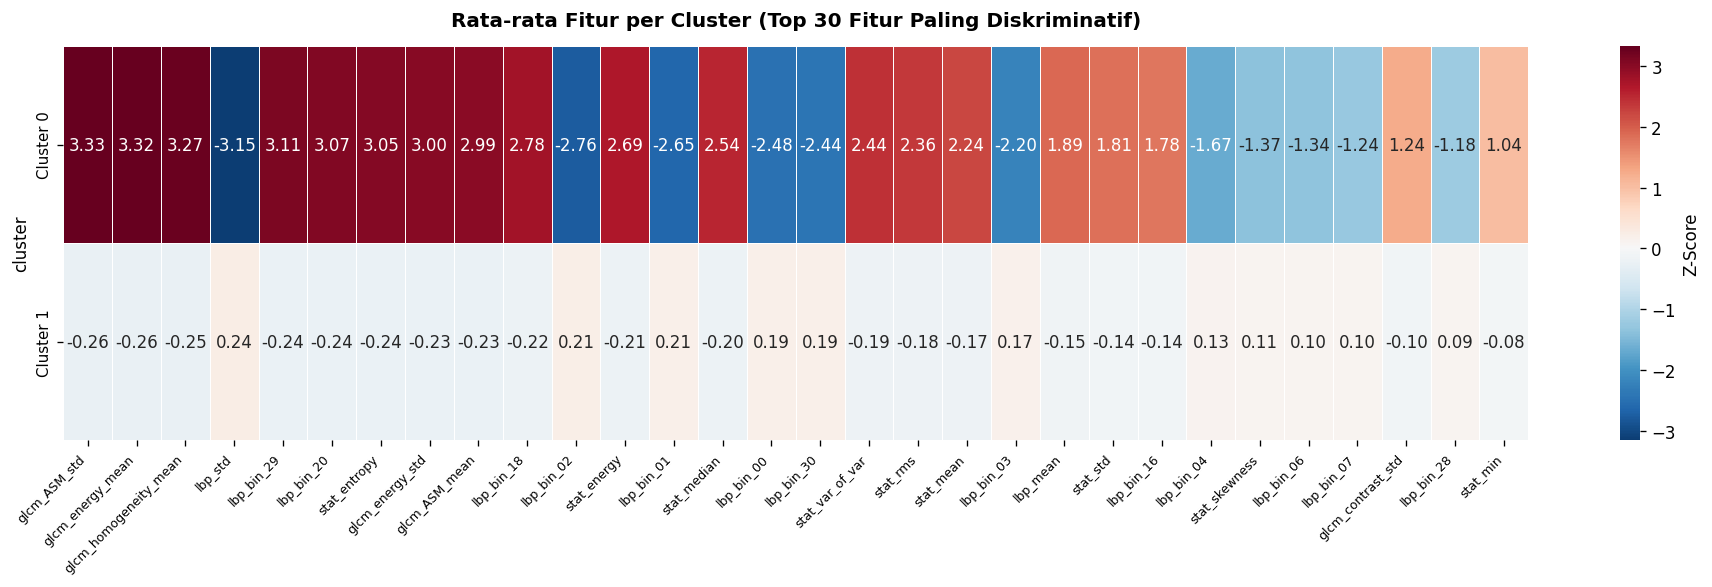

💾 Tersimpan: heatmap_fitur_cluster.png


In [43]:
df_tmp = pd.DataFrame(X_scaled, columns=feature_cols)
df_tmp['cluster'] = cluster_labels
cluster_means = df_tmp.groupby('cluster').mean()
top_feats = cluster_means.var().nlargest(30).index.tolist()

plt.figure(figsize=(16, 5))
sns.heatmap(
    cluster_means[top_feats],
    annot=True, fmt='.2f', cmap='RdBu_r', center=0,
    linewidths=0.3, linecolor='white',
    cbar_kws={'label': 'Z-Score'},
    yticklabels=[f'Cluster {c}' for c in cluster_means.index]
)
plt.title('Rata-rata Fitur per Cluster (Top 30 Fitur Paling Diskriminatif)',
          fontsize=12, fontweight='bold', pad=12)
plt.xticks(fontsize=7.5, rotation=45, ha='right')
plt.yticks(fontsize=9)
plt.tight_layout()
plt.savefig(f'{OUTPUT_PATH}/heatmap_fitur_cluster.png', bbox_inches='tight')
plt.show()
print('Tersimpan: heatmap_fitur_cluster.png')

## Copy Citra ke Folder per Cluster

In [44]:
folder = Path(DATASET_PATH)
file_map = {p.name: p for p in folder.rglob('*') if p.suffix.lower() in VALID_EXT}

copied = 0
for fname, clabel in zip(filenames, cluster_labels):
    if fname in file_map:
        dest_dir = Path(OUTPUT_PATH) / f'cluster_{clabel}'
        dest_dir.mkdir(parents=True, exist_ok=True)
        shutil.copy2(file_map[fname], dest_dir / fname)
        copied += 1

print(f'{copied} citra berhasil disalin ke subfolder per cluster')
for c in range(K_FINAL):
    n = sum(1 for l in cluster_labels if l == c)
    print(f' cluster_{c}/  →  {n} citra')

139 citra berhasil disalin ke subfolder per cluster
 cluster_0/  →  10 citra
 cluster_1/  →  129 citra
